In [ ]:
import os

# Edit these or override via env vars before running the notebook.
BASE_MODEL_PATH = "/projects/dsai/se_aieng/cai/causal/workspace/causaledit/MCPL-diffuser-flux/.cache/huggingface/models--stabilityai--stable-diffusion-3-medium-diffusers/snapshots/5fe80140eec27f0a4e1d02ea2b0b31d71ac38f75"
LOG_ROOT = os.environ.get('SD3_LOG_ROOT', './logs/logs_celebahq_simple_all')
DATA_ROOT = "/projects/dsai/se_aieng/cai/causal/workspace/causaledit/counterfactual-benchmark/datasets"


# DDIM inversion (initalise with MCPL pretrained)

In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys

from torchvision import transforms
from diffusers.models.controlnets.controlnet_sd3_causal import Causal_SD3ControlNetModel
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
import torch

size = 512

image_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

tensor_image_transforms = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize([0.5], [0.5]),
            ]
        )
        

/projects/dsai/se_aieng/cai/causal/workspace/.conda/envs/flux/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
'''Load pipeline'''
from diffusers.pipelines import StableDiffusion3InpaintPipeline_Adapter
from causal_modules.ddim_modules_sd3 import load_tokenizers_text_encoders,load_mcpl_embeddings,tokenize_prompt

load_dtype = torch.float16

base_model_path = BASE_MODEL_PATH
'''cond_text_contrastive'''
#model_dir_name = "download_model_testing"
model_dir_name = "2025-10-28T20-32-57-controlnet_textcond_constrastive_7attrsgeneration_text_global_after"
train_steps = 200000
# currently not train the T5 embeddings
controlnet_path = f"{LOG_ROOT}/{model_dir_name}/controlnet-steps-{train_steps}.safetensors"
embedding_1_path = f"{LOG_ROOT}/{model_dir_name}/learned_embeds_clip1_{train_steps}.safetensors"
embedding_2_path = f"{LOG_ROOT}/{model_dir_name}/learned_embeds_clip2_{train_steps}.safetensors"
embedding_3_path = f"{LOG_ROOT}/{model_dir_name}/learned_embeds_t5_{train_steps}.safetensors"

device = torch.device("cuda")
controlnet = Causal_SD3ControlNetModel.from_pretrained(controlnet_path,torch_dtype=load_dtype)
controlnet.eval()

# Load mcpl embedding

prompt = 'a human of @ and * and mouth and gender and ** and $ and #'
presudo_words= '@,*,mouth,gender,**,$,#'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')

# mcpl embeddings
tokenizers, text_encoders = load_tokenizers_text_encoders(base_model_path,load_dtype)
text_encoders = load_mcpl_embeddings([embedding_1_path,embedding_2_path,embedding_3_path], tokenizers, text_encoders,load_dtype)

pipe = StableDiffusion3InpaintPipeline_Adapter.from_pretrained(
    base_model_path, controlnet=controlnet,
    tokenizer = tokenizers[0],tokenizer_2 = tokenizers[1],tokenizer_3 = tokenizers[2],
    text_encoder=text_encoders[0],text_encoder_2=text_encoders[1],text_encoder_3=text_encoders[2],
    torch_dtype=load_dtype
)

# pipe.scheduler = DDIMScheduler(beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", clip_sample=False, set_alpha_to_one=False)
pipe.safety_checker = None
pipe.requires_safety_checker = False

# memory optimization.
pipe = pipe.to(device)


presudo_token_ids_one = tokenizers[0].encode(' '.join(presudo_list), add_special_tokens=False)
presudo_token_ids_two = tokenizers[1].encode(' '.join(presudo_list), add_special_tokens=False)
presudo_token_ids_three = tokenizers[2].encode(' '.join(presudo_list), add_special_tokens=False)

string_tokens_one = tokenize_prompt(tokenizers[0], prompt, max_sequence_length=77)
string_tokens_two = tokenize_prompt(tokenizers[1], prompt, max_sequence_length=77)
string_tokens_three = tokenize_prompt(tokenizers[2], prompt, max_sequence_length=77)
    


You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers
Loading checkpoint shards: 100%|█████████████████████████████████████████████████| 2/2 [00:01<00:00,  1.05it/s]


[Encoder 1] Loaded textual inversion embedding for '#</w>' (id=258).
[Encoder 1] Loaded textual inversion embedding for '$</w>' (id=259).
[Encoder 1] Loaded textual inversion embedding for '**</w>' (id=4441).
[Encoder 1] Loaded textual inversion embedding for '*</w>' (id=265).
[Encoder 1] Loaded textual inversion embedding for '@</w>' (id=287).
[Encoder 1] Loaded textual inversion embedding for 'gender</w>' (id=5906).
[Encoder 1] Loaded textual inversion embedding for 'mouth</w>' (id=4932).
[Encoder 2] Loaded textual inversion embedding for '#</w>' (id=258).
[Encoder 2] Loaded textual inversion embedding for '$</w>' (id=259).
[Encoder 2] Loaded textual inversion embedding for '**</w>' (id=4441).
[Encoder 2] Loaded textual inversion embedding for '*</w>' (id=265).
[Encoder 2] Loaded textual inversion embedding for '@</w>' (id=287).
[Encoder 2] Loaded textual inversion embedding for 'gender</w>' (id=5906).
[Encoder 2] Loaded textual inversion embedding for 'mouth</w>' (id=4932).
[Encoder

Loading pipeline components...: 100%|████████████████████████████████████████████| 9/9 [00:01<00:00,  6.43it/s]


In [3]:
'''from training set'''
import random
import pandas as pd
from torchvision.datasets import CelebA
from causal_datasets.celebahq_dataset import CelebAHQ
def dataset_load_path(data_root,dataset,split='train'):
    data_dir = data_root
    data = CelebAHQ(root=data_dir, split=split, transform=None, download=False)
    num_images = len(data)
    if 'simple' in dataset:
                selected_item = ['Smiling','Eyeglasses','Mouth_Slightly_Open','Male','Bald','Wearing_Lipstick','Wearing_Hat']
    elif 'complex' in dataset:
        pass
    else:
        AssertionError('no such {} dataset'.format(dataset))
    attribute_ids = [data.attr_names.index(attr) for attr in selected_item]
    metrics = {attr: torch.as_tensor(data.attr[:, attr_id], dtype=torch.float32) for attr, attr_id in zip(selected_item, attribute_ids)}

    attrs = torch.cat([metrics[attr].unsqueeze(1)
                            for attr in selected_item], dim=1)
    imglabel= attrs
    possible_values = {attr: torch.unique(values, dim=0) for attr, values in metrics.items()}
    
    img_id = random.randint(0,num_images)
    return data,imglabel,num_images

#img_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test/a_-1_128_4_12.png'
data,imglabel,num_images = dataset_load_path(data_root=DATA_ROOT,dataset='celebahq_simple',split='test')


tensor([[1., 0., 1., 0., 0., 1., 0.]])


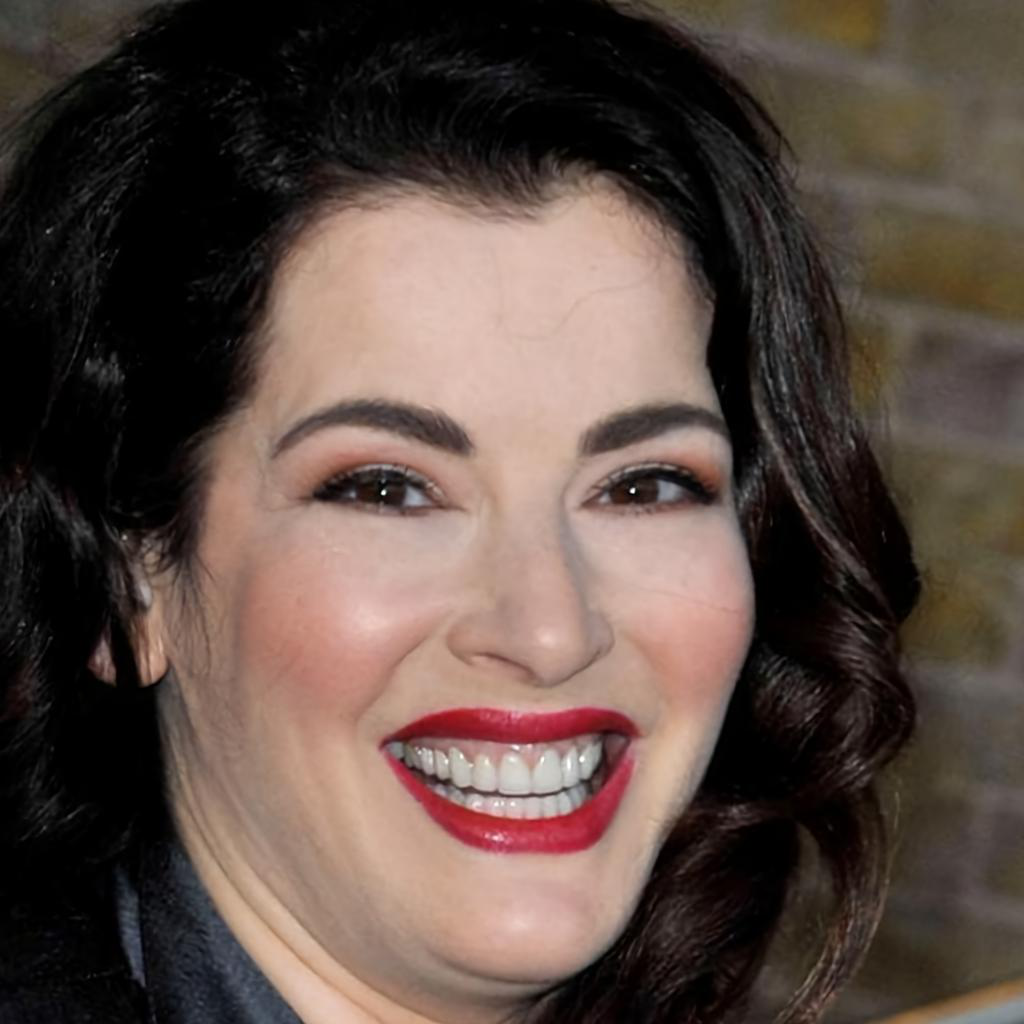

In [6]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
# valid (79,145,17,18,712)
# ablation (test2,test190,valid23,test25)
# limitation (test2,test357)
# Pressure test (test8951,test1002)
img_id = random.randint(0,num_images)
img_id=8
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)
img

100%|██████████████████████████████████████████████████████████████████████████| 50/50 [00:02<00:00, 18.55it/s]


save imgs in ./intervention_variable6.png


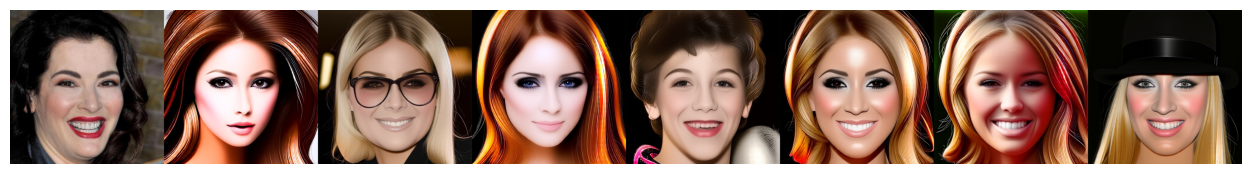

In [7]:
# Prompt2Prompt
from causal_modules.ddim_modules_sd3 import encode_prompt_pai,save_images_grid
from copy import deepcopy
import numpy as np
import os
from diffusers.utils.torch_utils import randn_tensor
input_image = img
if not input_image.mode == "RGB":
    input_image = input_image.convert("RGB")

original_img = input_image.copy()
original_img = original_transforms(original_img)
image = image_transforms(input_image) 

# PNP+direct inversion
# do intervention 
inter_value = 1- label.clone().squeeze()

# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 3.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)

image_lists = [np.asarray(original_img)]


shape = (
            1,
            16,
            int(512) // 8,
            int(512) // 8,
        )

generator = torch.Generator(0)

latents = randn_tensor(shape, generator=generator, device=pipe.device, dtype=load_dtype)

#final_im,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0).repeat(4, 1, 1, 1),text_label,prompt,presudo_list,num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,set_guidance_scale  = set_guidance_scale,intervention_indx=1,intervention_values=inter_value[1],return_PIL=True,blend_word=blend_word)
with torch.no_grad():
    for inter_id in range(0,7,1):
    #for inter_id in [1]:
        images = []
        #inter_value  = -1   
        s_step = 0


        DSCM_labels = label.clone()

        # Set attribute `inter_id` to its complemented value, per sample
        DSCM_labels[:, inter_id] = inter_value[inter_id]

        # If we're intervening on attribute 0, enforce a dependency:
        # attr2 follows the (complemented) value of attr0, per sample.
        if inter_id == 0:
            DSCM_labels[:, 2] = inter_value[0]

        DSCM_labels = DSCM_labels.to(pipe.device)

        prompt_embeds, pooled_prompt_embeds = encode_prompt_pai(
                                text_encoders=[pipe.text_encoder, pipe.text_encoder_2,pipe.text_encoder_3],
                                tokenizers=[None, None,None],
                                text_input_ids_list=[string_tokens_one, string_tokens_two,string_tokens_three],
                                max_sequence_length=77,
                                prompt=prompt,
                                label = DSCM_labels.to(dtype=load_dtype).unsqueeze(2),
                                presudo_token_lists =[presudo_token_ids_one,presudo_token_ids_two,presudo_token_ids_three],
                                weight_dtype = load_dtype,
                                is_negative_embeddings = False
        )
        # null embeddings
        negative_prompt_embeds, negative_pooled_prompt_embeds = encode_prompt_pai(
                                text_encoders=[pipe.text_encoder, pipe.text_encoder_2,pipe.text_encoder_3],
                                tokenizers=[pipe.tokenizer, pipe.tokenizer_2,pipe.tokenizer_3],
                                text_input_ids_list=[None, None,None],
                                max_sequence_length=77,
                                prompt="",
                                label = DSCM_labels.to(dtype=load_dtype).unsqueeze(2),
                                presudo_token_lists =[presudo_token_ids_one,presudo_token_ids_two,presudo_token_ids_three],
                                weight_dtype = load_dtype,
                                is_negative_embeddings = True
        )

        if image.dim() == 3:
            image = image.unsqueeze(0)
        interved_image = pipe(image = image,height = 512,width = 512,
                              generator = generator,
                              latents= latents,
                              guidance_scale = set_guidance_scale,
                              num_inference_steps=num_steps,
                              prompt_embeds = prompt_embeds,
                              negative_prompt_embeds= negative_prompt_embeds,
                              pooled_prompt_embeds = pooled_prompt_embeds,
                              negative_pooled_prompt_embeds=negative_pooled_prompt_embeds,
        ).images[0]
        image_lists.append(np.asarray(interved_image))
            
        
    output='./'
    save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
    save_images_grid([image_lists],(1,8),save_path)
    print('save imgs in {}'.format(save_path))



# try inverse-based editing

tensor([[1., 0., 0., 0., 0., 1., 0.]])


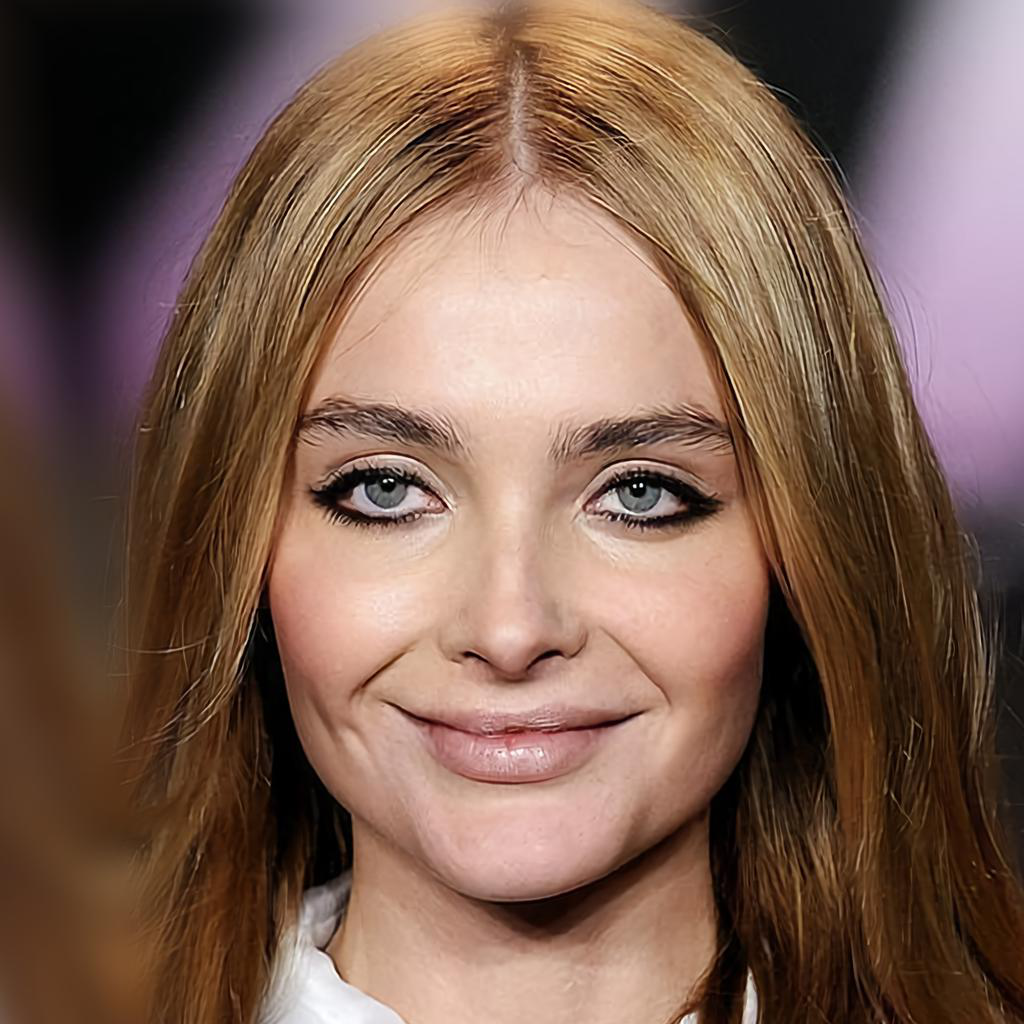

In [10]:
# paper image id (190,8385,2457,2184,3627,5694)
# female (8385,3393,6942)
# valid (79,145,17,18,712)
# ablation (test2,test190,valid23,test25)
# limitation (test2,test357)
# Pressure test (test8951,test1002)
#17
img_id = random.randint(0,num_images)
img_id=5
img,label = data[img_id][0],imglabel[img_id].unsqueeze(0)
print(label)
img

50it [00:04, 10.25it/s]
50it [00:04, 10.24it/s]
50it [00:04, 10.24it/s]


save imgs in ./intervention_variable2.png


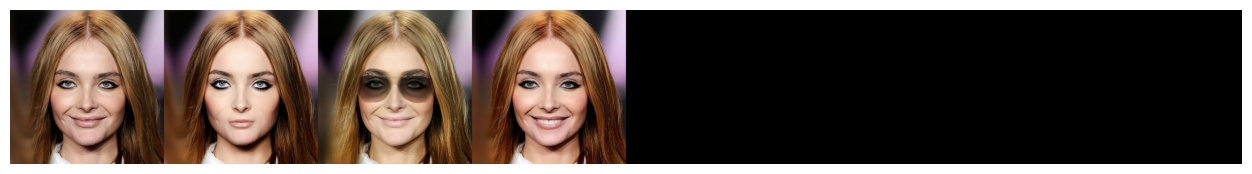

In [11]:
from causal_modules.ddim_modules_sd3 import encode_prompt_pai,save_images_grid,FlowEditSD3
from copy import deepcopy
import numpy as np
import os
import matplotlib.pyplot as plt
from diffusers.utils.torch_utils import randn_tensor
T_steps = 50
n_avg = 1
src_guidance_scale = 1.5
tar_guidance_scale = 2.5
n_min = 10
n_max = 50
seed = 49

# set seed
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
device = pipe.device
inter_value = 1- label.clone().squeeze()

input_image = img
if not input_image.mode == "RGB":
    input_image = input_image.convert("RGB")

original_img = input_image.copy()
original_img = original_transforms(original_img)
image = image_transforms(input_image) 
image_src = pipe.image_processor.preprocess(image)
image_src = image_src.to(device).to(dtype=load_dtype)

image_lists = [np.asarray(original_img)]
with torch.autocast("cuda"), torch.inference_mode():
    x0_src_denorm = pipe.vae.encode(image_src).latent_dist.mode()
x0_src = (x0_src_denorm - pipe.vae.config.shift_factor) * pipe.vae.config.scaling_factor
# send to cuda
x0_src = x0_src.to(device)

#for inter_id in range(0,7,1):
#for inter_id in [5,6]:
for inter_id in [0,1,2]:
#for inter_id in [3]:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if inter_id in [6]: 
        src_guidance_scale = 1.0
        tar_guidance_scale = 2.5
        n_min = 10
        n_max = 50
    elif inter_id in [3]: 
        src_guidance_scale = 1.0
        tar_guidance_scale = 1.5
        n_min = 10
        n_max = 50
    else:
        src_guidance_scale = 1.0
        tar_guidance_scale = 1.8
        n_min = 0
        n_max = 50

    images = []
    #inter_value  = -1   
    s_step = 0

    DSCM_labels = label.clone()

    # Set attribute `inter_id` to its complemented value, per sample
    DSCM_labels[:, inter_id] = inter_value[inter_id]

    # If we're intervening on attribute 0, enforce a dependency:
    # attr2 follows the (complemented) value of attr0, per sample.
    if inter_id == 0:
        DSCM_labels[:, 2] = inter_value[0]

    DSCM_labels = DSCM_labels.to(pipe.device)

    x0_tar = FlowEditSD3(pipe,
                        pipe.scheduler,
                        x0_src.clone(),
                        prompt,
                        presudo_list,
                        label.clone().to(pipe.device),
                        DSCM_labels.to(pipe.device),
                        negative_prompt="",
                        T_steps= T_steps,
                        n_avg= n_avg,
                        src_guidance_scale= src_guidance_scale,
                        tar_guidance_scale = tar_guidance_scale,
                        n_min= n_min,
                        n_max= n_max,)

    x0_tar_denorm = (x0_tar / pipe.vae.config.scaling_factor) + pipe.vae.config.shift_factor
    with torch.autocast("cuda"), torch.inference_mode():
        image_tar = pipe.vae.decode(x0_tar_denorm, return_dict=False)[0]
        image_tar = pipe.image_processor.postprocess(image_tar)

    image_lists.append(np.asarray(image_tar[0]))
            
output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(inter_id))
save_images_grid([image_lists],(1,8),save_path)
print('save imgs in {}'.format(save_path))

    